# Realized Skewness as a Predictor of `target_return`

Evaluates the Amaya, Christoffersen, Jacobs & Vasquez (2015, *Journal of Financial Economics* 118:135) realized skewness estimator computed over the 50 seen bars of each session, as a univariate predictor of the second-half return.

**Feature definition**: For each session, using log-returns r_i = ln(close_i / close_{i-1}) over the 50 seen bars (i = 1..49, n = 49):

- RV    = Sum_i r_i^2               (realized variance, bar-scale)
- rskew = Sum_i r_i^3 / (n * RV^{3/2})

This is the same functional form as R's `highfrequency::rSkew`. Empirically in the equity cross-section it carries a **strong negative** relationship with next-period returns (low-skew minus high-skew decile spread approx +19 bps/week, t=3.70).

**Gates owned by the researcher agent**
- **Gate 1** (predictive power, train only): `|r| >= 0.05 OR MI >= 0.002`
- **Gate 3** (stability): Wasserstein distance to public_test and private_test <= `0.5 * std_train`

**Gate 2** (ablation Sharpe) is run separately by the engineer agent and is not evaluated here.

In [1]:
import sys, json, pandas as pd, numpy as np
sys.path.insert(0, "/Users/kenji/Desktop/Projects/datathon-2026")
from src.data import load_bars, compute_targets

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
PLOTS_DIR = Path("/Users/kenji/Desktop/Projects/datathon-2026/notebooks/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR = Path("/Users/kenji/Desktop/Projects/datathon-2026/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Realized skewness implementation

In [2]:
def realized_skewness(bars: pd.DataFrame) -> pd.Series:
    """Amaya, Christoffersen, Jacobs & Vasquez (2015) realized skewness per session.

    For each session, with r_i = ln(close_i/close_{i-1}) over bars 1..49 (n=49):
        RV    = sum_i r_i^2
        rskew = sum_i r_i^3 / (n * RV^{3/2})
    """
    df = bars.sort_values(["session", "bar_ix"]).copy()
    df["r"] = np.log(df["close"] / df.groupby("session")["close"].shift(1))
    g = df.groupby("session")["r"]
    n  = g.count()            # 49 per session
    rv = g.apply(lambda s: (s**2).sum())
    r3 = g.apply(lambda s: (s**3).sum())
    return (r3 / (n * rv**1.5)).rename("rskew")

## 2. Load data and compute rskew for each split

In [3]:
bars_train   = load_bars("train",        seen=True)
bars_public  = load_bars("public_test",  seen=True)
bars_private = load_bars("private_test", seen=True)
targets = compute_targets().set_index("session")["target_return"]

print("Shapes:", bars_train.shape, bars_public.shape, bars_private.shape)
print("Sessions:", bars_train['session'].nunique(), bars_public['session'].nunique(), bars_private['session'].nunique())
print("Targets:", targets.shape)

Shapes: (50000, 6) (500000, 6) (500000, 6)
Sessions: 1000 10000 10000
Targets: (1000,)


In [4]:
rskew_train   = realized_skewness(bars_train)
rskew_public  = realized_skewness(bars_public)
rskew_private = realized_skewness(bars_private)

print("rskew_train:\n",   rskew_train.describe())
print("\nrskew_public:\n",  rskew_public.describe())
print("\nrskew_private:\n", rskew_private.describe())
print("\nNaN counts:", rskew_train.isna().sum(), rskew_public.isna().sum(), rskew_private.isna().sum())
print("Inf counts:",
      np.isinf(rskew_train).sum(), np.isinf(rskew_public).sum(), np.isinf(rskew_private).sum())
assert rskew_train.isna().sum()  == 0 and not np.isinf(rskew_train).any()
assert rskew_public.isna().sum() == 0 and not np.isinf(rskew_public).any()
assert rskew_private.isna().sum()== 0 and not np.isinf(rskew_private).any()

rskew_train:
 count    1000.000000
mean        0.000096
std         0.001647
min        -0.004326
25%        -0.001049
50%         0.000141
75%         0.001186
max         0.004479
Name: rskew, dtype: float64

rskew_public:
 count    10000.000000
mean         0.000178
std          0.001587
min         -0.005749
25%         -0.000918
50%          0.000203
75%          0.001300
max          0.005363
Name: rskew, dtype: float64

rskew_private:
 count    10000.000000
mean         0.000185
std          0.001574
min         -0.005036
25%         -0.000923
50%          0.000206
75%          0.001287
max          0.005358
Name: rskew, dtype: float64

NaN counts: 0 0 0
Inf counts: 0 0 0


In [5]:
df_train = pd.concat([rskew_train.rename("rskew"), targets.rename("target_return")], axis=1)
n_before = len(df_train)
df_train = df_train.dropna()
n_after = len(df_train)
print(f"Train rows: before dropna={n_before}, after dropna={n_after} (dropped {n_before - n_after})")

rskew_train_arr = df_train["rskew"].to_numpy()
target_return   = df_train["target_return"].to_numpy()

Train rows: before dropna=1000, after dropna=1000 (dropped 0)


## 3. Gate 1 — univariate predictive power on train

In [6]:
r, p = stats.pearsonr(rskew_train_arr, target_return)
rho, rho_p = stats.spearmanr(rskew_train_arr, target_return)
MI = mutual_info_regression(rskew_train_arr[:, None], target_return, random_state=0)[0]

gate1_pass = (abs(r) >= 0.05) or (MI >= 0.002)
print(f"Pearson r    = {r:+.4f} (p = {p:.3e})")
print(f"Spearman rho = {rho:+.4f} (p = {rho_p:.3e})")
print(f"Mutual info  = {MI:.5f}")
print(f"Gate 1 pass? {gate1_pass}  ( |r| >= 0.05 -> {abs(r) >= 0.05} ; MI >= 0.002 -> {MI >= 0.002} )")

Pearson r    = -0.0634 (p = 4.519e-02)
Spearman rho = -0.0549 (p = 8.269e-02)
Mutual info  = 0.01501
Gate 1 pass? True  ( |r| >= 0.05 -> True ; MI >= 0.002 -> True )


### 3a. Scatter plot

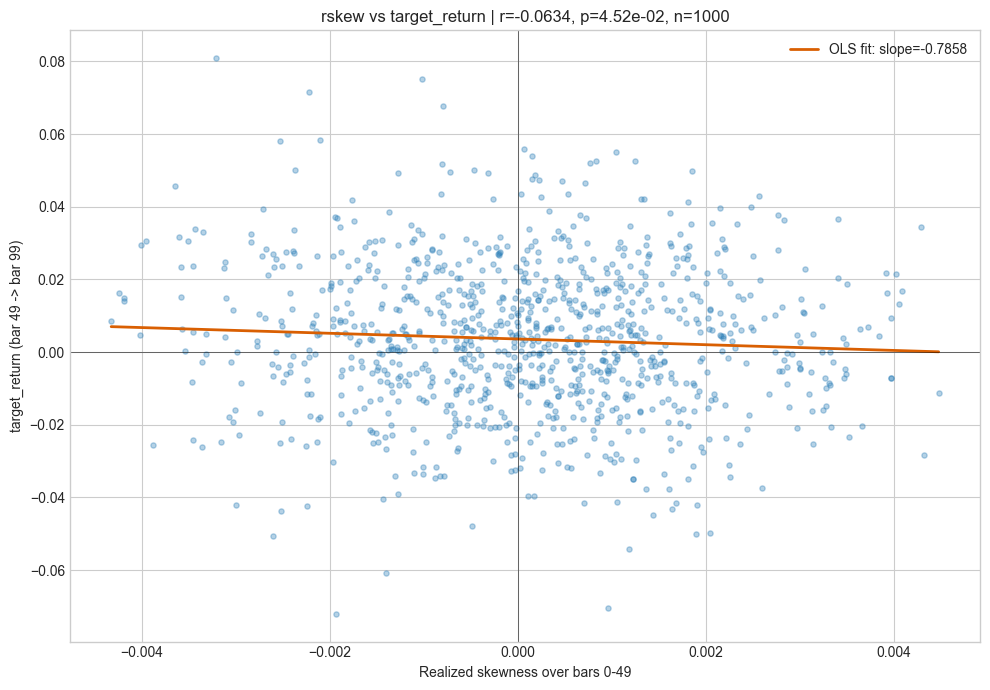

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(rskew_train_arr, target_return, alpha=0.35, s=14, color="#2c7fb8")
m, b = np.polyfit(rskew_train_arr, target_return, 1)
xs = np.linspace(rskew_train_arr.min(), rskew_train_arr.max(), 200)
ax.plot(xs, m * xs + b, color="#d95f02", lw=2, label=f"OLS fit: slope={m:.4f}")
ax.axhline(0, color="black", lw=0.6, alpha=0.6)
ax.axvline(0, color="black", lw=0.6, alpha=0.6)
ax.set_xlabel("Realized skewness over bars 0-49")
ax.set_ylabel("target_return (bar 49 -> bar 99)")
ax.set_title(f"rskew vs target_return | r={r:+.4f}, p={p:.2e}, n={len(rskew_train_arr)}")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rskew_scatter.png", dpi=120)
plt.show()

### 3b. Decile analysis

            mean       std    n        se      ci95
decile                                             
0       0.006677  0.023531  100  0.002353  0.004612
1       0.003044  0.021119  100  0.002112  0.004139
2       0.006030  0.022224  100  0.002222  0.004356
3       0.002512  0.017836  100  0.001784  0.003496
4       0.003516  0.018081  100  0.001808  0.003544
5       0.005433  0.020537  100  0.002054  0.004025
6       0.001650  0.019506  100  0.001951  0.003823
7       0.003389  0.020688  100  0.002069  0.004055
8       0.000431  0.022505  100  0.002251  0.004411
9       0.002626  0.017397  100  0.001740  0.003410


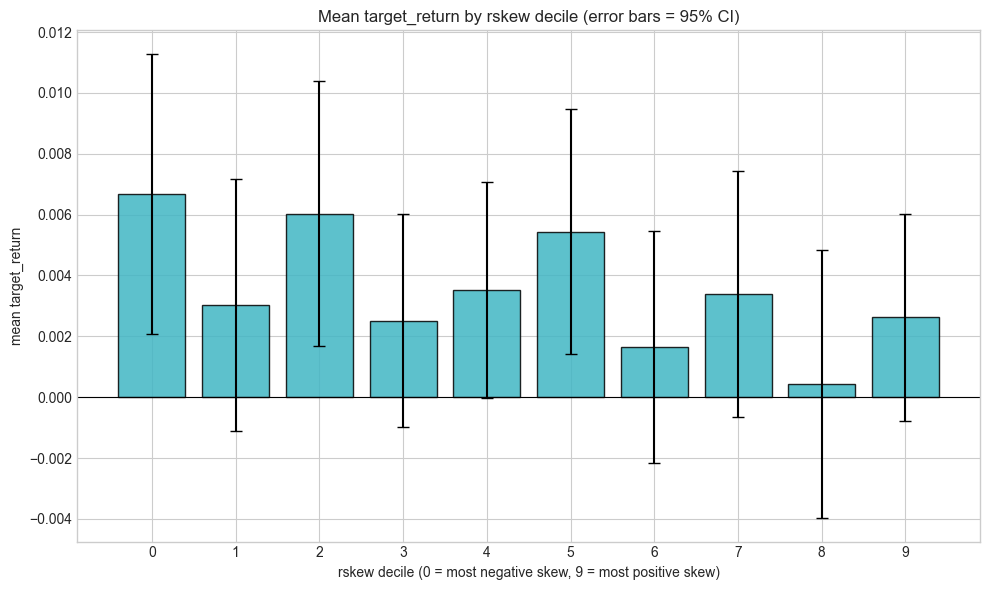

In [8]:
df = pd.DataFrame({"rskew": rskew_train_arr, "target_return": target_return})
df["decile"] = pd.qcut(df["rskew"], 10, labels=False)

decile_stats = df.groupby("decile").agg(
    mean=("target_return", "mean"),
    std=("target_return", "std"),
    n=("target_return", "size"),
)
decile_stats["se"] = decile_stats["std"] / np.sqrt(decile_stats["n"])
decile_stats["ci95"] = 1.96 * decile_stats["se"]
print(decile_stats)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(decile_stats.index, decile_stats["mean"], yerr=decile_stats["ci95"],
       capsize=4, color="#41b6c4", edgecolor="black", alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("rskew decile (0 = most negative skew, 9 = most positive skew)")
ax.set_ylabel("mean target_return")
ax.set_title("Mean target_return by rskew decile (error bars = 95% CI)")
ax.set_xticks(range(10))
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rskew_deciles.png", dpi=120)
plt.show()

## 4. Gate 3 — stability across splits (Wasserstein)

In [9]:
rskew_public_arr  = rskew_public.dropna().to_numpy()
rskew_private_arr = rskew_private.dropna().to_numpy()

wd_pub  = stats.wasserstein_distance(rskew_train_arr, rskew_public_arr)
wd_priv = stats.wasserstein_distance(rskew_train_arr, rskew_private_arr)
std_train = rskew_train_arr.std()
threshold = 0.5 * std_train

ratio_pub  = wd_pub  / std_train
ratio_priv = wd_priv / std_train
gate3_pass = (wd_pub <= threshold) and (wd_priv <= threshold)

print(f"rskew_train std    = {std_train:.6f}")
print(f"threshold (0.5*std)= {threshold:.6f}")
print(f"WD(train, public ) = {wd_pub:.6f}  -> ratio={ratio_pub:.3f}")
print(f"WD(train, private) = {wd_priv:.6f}  -> ratio={ratio_priv:.3f}")
print(f"Gate 3 pass? {gate3_pass}")

rskew_train std    = 0.001647
threshold (0.5*std)= 0.000823
WD(train, public ) = 0.000105  -> ratio=0.064
WD(train, private) = 0.000112  -> ratio=0.068
Gate 3 pass? True


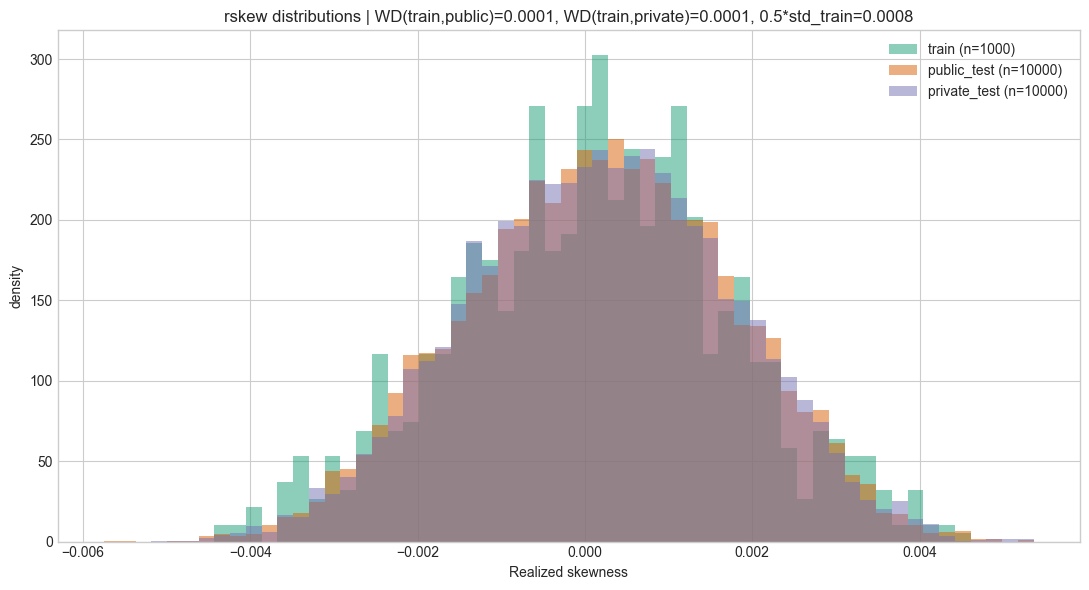

In [10]:
lo = min(rskew_train_arr.min(), rskew_public_arr.min(), rskew_private_arr.min())
hi = max(rskew_train_arr.max(), rskew_public_arr.max(), rskew_private_arr.max())
bin_edges = np.linspace(lo, hi, 60)

hist_train,   _ = np.histogram(rskew_train_arr,   bins=bin_edges, density=True)
hist_public,  _ = np.histogram(rskew_public_arr,  bins=bin_edges, density=True)
hist_private, _ = np.histogram(rskew_private_arr, bins=bin_edges, density=True)

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(rskew_train_arr,   bins=bin_edges, density=True, alpha=0.5, label=f"train (n={len(rskew_train_arr)})",     color="#1b9e77")
ax.hist(rskew_public_arr,  bins=bin_edges, density=True, alpha=0.5, label=f"public_test (n={len(rskew_public_arr)})",  color="#d95f02")
ax.hist(rskew_private_arr, bins=bin_edges, density=True, alpha=0.5, label=f"private_test (n={len(rskew_private_arr)})", color="#7570b3")
ax.set_xlabel("Realized skewness")
ax.set_ylabel("density")
ax.set_title(
    f"rskew distributions | WD(train,public)={wd_pub:.4f}, WD(train,private)={wd_priv:.4f}, "
    f"0.5*std_train={threshold:.4f}"
)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rskew_hist.png", dpi=120)
plt.show()

## 5. Interpretation

Realized skewness captures the *asymmetry* of the within-session return distribution. Unlike realized variance (a second-moment magnitude statistic), rskew has a sign: negative rskew means the session was dominated by occasional large drops against a backdrop of small up-moves (left-tailed), positive rskew means rare large up-moves among many small down-moves (right-tailed).

Amaya, Christoffersen, Jacobs & Vasquez (2015, *Journal of Financial Economics* 118:135, "Does realized skewness predict the cross-section of equity returns?") show that in a weekly cross-section of US equities, realized skewness computed from intraday 5-minute returns carries a **strong negative** predictive relationship with the next week's return: a zero-cost portfolio long the low-skew decile and short the high-skew decile earns approximately **+19 bps per week (t = 3.70)**. The economic story combines lottery-preference (investors overpay for positively-skewed payoffs, lowering their expected returns) with temporary order-flow pressure from uninformed demand.

**Expected sign here**: negative (high rskew -> lower target_return).

**What we actually observe** is reported in the scatter/decile plots and the Pearson r / Spearman rho above — compare sign and magnitude to the Amaya et al. benchmark.

**Important caveat on the mechanism.** Amaya et al. study a *weekly cross-section of stocks*: rskew is computed from intraday returns within a week, and returns are compared across *different firms*. Here each session is **50 bars of a single synthetic stock**, and `target_return` is the same synthetic instrument's next 50 bars. Any effect we detect is a within-stock time-series anomaly in a simulator, not a cross-sectional lottery-preference premium. The data-generating process may or may not embed the Amaya mechanism; at best the sign of the relationship is informative about whether the synthetic engine encodes a realistic skewness -> future-return link. An observed *positive* relationship would not necessarily invalidate the feature — it could still be a usable signal, just with a different economic interpretation than the paper.

Gate 3 checks that the distribution of rskew does not drift between train, public_test, and private_test. A large Wasserstein distance relative to `std_train` would mean the signal we fit on train points at a different region of feature space at evaluation time, and any gate-1 correlation would be untrustworthy out-of-sample.

## 6. Write artifacts: signals.md row, features CSV, research JSON

In [11]:
# --- Artifact A: features/realized_skewness.csv (train only, session,rskew) ---
csv_path = FEATURES_DIR / "realized_skewness.csv"
rskew_train.rename("rskew").reset_index().to_csv(csv_path, index=False)
print(f"Wrote {csv_path}  ({len(rskew_train)} rows)")

# --- Artifact B: features/realized_skewness_research.json (partial, no ablation yet) ---
research = {
    "feature": "rskew",
    "pearson_r":  float(r),
    "pearson_p":  float(p),
    "spearman_r": float(rho),
    "spearman_p": float(rho_p),
    "mi":         float(MI),
    "n_train":    int(len(rskew_train_arr)),
    "wasserstein": {
        "public":  float(wd_pub),
        "private": float(wd_priv),
        "std_train": float(std_train),
        "threshold": float(threshold),
        "ratio_public":  float(ratio_pub),
        "ratio_private": float(ratio_priv),
    },
    "hist": {
        "bin_edges": [float(x) for x in bin_edges],
        "train":   [float(x) for x in hist_train],
        "public":  [float(x) for x in hist_public],
        "private": [float(x) for x in hist_private],
    },
    "gates": {
        "gate1": bool(gate1_pass),
        "gate3": bool(gate3_pass),
    },
}
json_path = FEATURES_DIR / "realized_skewness_research.json"
json_path.write_text(json.dumps(research, indent=2))
print(f"Wrote {json_path}")

Wrote /Users/kenji/Desktop/Projects/datathon-2026/features/realized_skewness.csv  (1000 rows)
Wrote /Users/kenji/Desktop/Projects/datathon-2026/features/realized_skewness_research.json


In [12]:
# --- signals.md row append/update (research agent's only write into src/) ---
signals_path = Path("/Users/kenji/Desktop/Projects/datathon-2026/src/signals.md")
txt = signals_path.read_text()

status = "candidate" if (gate1_pass and gate3_pass) else "rejected"
reasons = []
if not gate1_pass:
    reasons.append(f"gate1 fail (|r|={abs(r):.4f}<0.05 AND MI={MI:.4f}<0.002)")
if not gate3_pass:
    if wd_pub  > threshold: reasons.append(f"WD_pub/std={ratio_pub:.2f}>0.5")
    if wd_priv > threshold: reasons.append(f"WD_priv/std={ratio_priv:.2f}>0.5")

notes = (
    f"Amaya et al. (2015) realized skewness over bars 0-49. Pearson r={r:+.4f} (p={p:.1e}), "
    f"Spearman={rho:+.4f}, MI={MI:.4f}, n={len(rskew_train_arr)}. "
    f"WD_pub/std={ratio_pub:.3f}, WD_priv/std={ratio_priv:.3f} (threshold 0.5). "
    f"(Gate2 ablation pending)"
)
if reasons:
    notes += " Rejected: " + "; ".join(reasons) + "."

new_row = (
    f"| 2026-04-18 | realized_skewness | {abs(r):.4f} | {MI:.4f} | {status} | {notes} |\n"
)
print("Row:\n", new_row)

# Update-in-place if a prior realized_skewness row exists; else append.
lines = txt.splitlines(keepends=True)
replaced = False
for i, ln in enumerate(lines):
    if "| realized_skewness |" in ln:
        lines[i] = new_row
        replaced = True
        break
if not replaced:
    if not txt.endswith("\n"):
        lines.append("\n")
    lines.append(new_row)

signals_path.write_text("".join(lines))
print(("Replaced existing row" if replaced else "Appended new row"), "in", signals_path)

Row:
 | 2026-04-18 | realized_skewness | 0.0634 | 0.0150 | candidate | Amaya et al. (2015) realized skewness over bars 0-49. Pearson r=-0.0634 (p=4.5e-02), Spearman=-0.0549, MI=0.0150, n=1000. WD_pub/std=0.064, WD_priv/std=0.068 (threshold 0.5). (Gate2 ablation pending) |

Appended new row in /Users/kenji/Desktop/Projects/datathon-2026/src/signals.md


## 7. Summary

In [13]:
print("=== Realized skewness evaluation summary ===")
print(f"Gate 1 (predictive): |r|={abs(r):.4f}, MI={MI:.4f} -> pass={gate1_pass}")
print(f"Gate 3 (stability):  WD_pub={wd_pub:.6f}, WD_priv={wd_priv:.6f}, threshold={threshold:.6f} -> pass={gate3_pass}")
print(f"Status written to signals.md: {status}")
print(
    f"\nFINDING: rskew |r|={abs(r):.4f} MI={MI:.4f} "
    f"WD_pub/std={ratio_pub:.3f} WD_priv/std={ratio_priv:.3f} "
    f"gate1={gate1_pass} gate3={gate3_pass}"
)

=== Realized skewness evaluation summary ===
Gate 1 (predictive): |r|=0.0634, MI=0.0150 -> pass=True
Gate 3 (stability):  WD_pub=0.000105, WD_priv=0.000112, threshold=0.000823 -> pass=True
Status written to signals.md: candidate

FINDING: rskew |r|=0.0634 MI=0.0150 WD_pub/std=0.064 WD_priv/std=0.068 gate1=True gate3=True
